<a href="https://colab.research.google.com/github/TanyaGupta37/ML-Lab/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

red['type'] = 0
white['type'] = 1

df = pd.concat([red, white], ignore_index=True)

print("Shape:", df.shape)
df.head()

Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [3]:
df['label'] = (df['quality'] >= 6).astype(int)

X = df.drop(columns=['quality', 'label']).values
y = df['label'].values

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)
print("Class distribution — Bad (0):", (y==0).sum(), "| Good (1):", (y==1).sum())

Feature Shape: (6497, 12)
Target Shape: (6497,)
Class distribution — Bad (0): 2384 | Good (1): 4113


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5197, 12)
Testing Shape: (1300, 12)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaled Training Data Sample:")
print(X_train[:5])

Scaled Training Data Sample:
[[-0.46822898 -0.59951186  0.20546655  0.4646116  -0.71280142  0.31165933
   0.34356569 -0.29614553 -0.16888369 -1.0832659   0.01376574  0.56512866]
 [ 0.85149992 -0.35284877  1.10406349 -0.70299854  1.06747    -1.4087346
  -1.84751841 -0.20307163  0.26967864  0.59857677  1.60871671 -1.76950857]
 [ 0.38571325  2.32961232 -2.14471006 -0.70299854  0.2347624   0.02492701
  -1.29529396 -0.32606213  1.20945505  0.26220824  1.10504798 -1.76950857]
 [-1.55506455  0.20214318  0.06722087 -0.89065017 -0.79894359 -1.00730935
  -0.61837367 -1.49280991  0.958848   -1.01599219  1.0211032   0.56512866]
 [-0.46822898 -0.47618032  1.65704622  2.07007555 -0.0810922   0.08227347
   0.45044784  1.1332036  -0.67009777 -0.27598142 -0.99357172  0.56512866]]


In [6]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=12))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6418 - loss: 0.6616 - val_accuracy: 0.6933 - val_loss: 0.5653
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7068 - loss: 0.5554 - val_accuracy: 0.7423 - val_loss: 0.5172
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7277 - loss: 0.5300 - val_accuracy: 0.7529 - val_loss: 0.5004
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7351 - loss: 0.5189 - val_accuracy: 0.7606 - val_loss: 0.4910
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7452 - loss: 0.5115 - val_accuracy: 0.7663 - val_loss: 0.4845
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7474 - loss: 0.5054 - val_accuracy: 0.7731 - val_loss: 0.4803
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7496 - loss: 0.5013 - val_accuracy: 0.7827 - val_loss: 0.4787
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7573 - loss: 0.4977 - val_accuracy: 0.

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7562 - loss: 0.5101
Test Accuracy: 0.7561538219451904
Test Loss: 0.5100886225700378


In [11]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(y_pred[:10])

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]]


In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[289 162]
 [155 694]]


In [13]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7561538461538462


In [14]:
print(classification_report(y_test, y_pred, target_names=['Bad (0)', 'Good (1)']))

              precision    recall  f1-score   support

     Bad (0)       0.65      0.64      0.65       451
    Good (1)       0.81      0.82      0.81       849

    accuracy                           0.76      1300
   macro avg       0.73      0.73      0.73      1300
weighted avg       0.76      0.76      0.76      1300



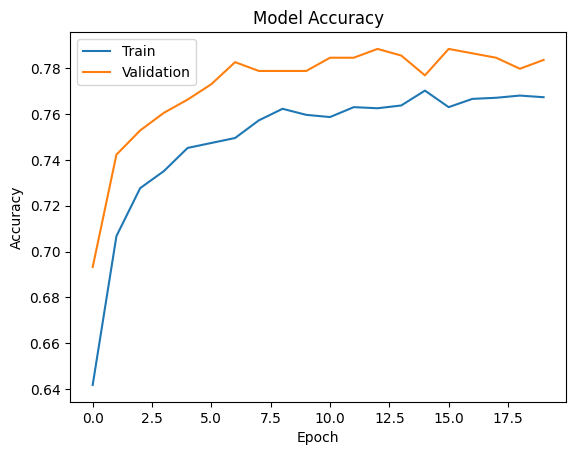

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()